In [1]:
import rasterio
import math
import numpy as np
import geopandas as gpd
import sys
import matplotlib.pyplot as plt

from rasterio.plot import plotting_extent

# Import necessary cross validation functions

In [2]:
sys.path.append('../src/nlr_ghe_screen/processing/') 
from land_cross_validation import (
    tiles_for_bbox,
    get_tile_data,
    merge_and_save_tiles,
    cross_validate_land,
)

from elevation import clip_raster_to_shapes

from geometry import classify_geometry

# Setup global variables

In [3]:
YEAR = 2021          # 2020 or 2021
VERSION = "v200"      # "v100" for 2020, "v200" for 2021
OUTPUT_TIF = "../src/imports/worldcover_clip.tif"
 
BASE_URL = f"https://esa-worldcover.s3.amazonaws.com/{VERSION}/{YEAR}/map"

# Create plotting function

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

CLASS_CODES = {
    10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland",
    50: "Built-up", 60: "Bare / sparse vegetation", 70: "Snow and ice",
    80: "Permanent water bodies", 90: "Herbaceous wetland",
    95: "Mangroves", 100: "Moss and lichen",
}

WORLDCOVER_CLASSES = {
    10:  ("Tree cover",               "#006400"),
    20:  ("Shrubland",                "#ffbb22"),
    30:  ("Grassland",                "#ffff4c"),
    40:  ("Cropland",                 "#f096ff"),
    50:  ("Built-up",                 "#fa0000"),
    60:  ("Bare / sparse vegetation", "#b4b4b4"),
    70:  ("Snow and ice",             "#f0f0f0"),
    80:  ("Permanent water bodies",   "#0064c8"),
    90:  ("Herbaceous wetland",       "#0096a0"),
    95:  ("Mangroves",                "#00cf75"),
    100: ("Moss and lichen",          "#fae6a0"),
}

def plot_shapes(idx, gdf, clips):
    arr, transform = clips[idx]
    fig, ax = plt.subplots(figsize=(8, 8))
    extent = plotting_extent(arr, transform)

    # Pull out only the valid (unmasked) pixel values before finding
    # unique classes — masked arrays otherwise return an unhashable
    # MaskedConstant placeholder for the masked-out pixels
    if np.ma.isMaskedArray(arr):
        valid_values = arr.compressed()
    else:
        valid_values = arr.ravel()

    present_classes = sorted(int(c) for c in np.unique(valid_values) if c in WORLDCOVER_CLASSES)

    colors = [WORLDCOVER_CLASSES[c][1] for c in present_classes]
    cmap = ListedColormap(colors)
    cmap.set_bad(alpha=0)  # render masked/nodata pixels as transparent

    boundaries = present_classes + [present_classes[-1] + 1]
    norm = BoundaryNorm(boundaries, cmap.N)

    im = ax.imshow(
        arr,
        extent=extent,
        cmap=cmap,
        norm=norm,
        interpolation="none",
    )

    gdf.loc[[idx]].boundary.plot(ax=ax, color="black", linewidth=1.5)
    ax.set_title(f"Shape {idx}")

    legend_handles = [
        mpatches.Patch(color=WORLDCOVER_CLASSES[c][1], label=WORLDCOVER_CLASSES[c][0])
        for c in present_classes
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        title="Land cover class",
    )

    plt.tight_layout()
    plt.show()

# Cross Validate Green Spaces

In [5]:
raster_src = rasterio.open(OUTPUT_TIF)
arr = raster_src.read(1)

gdf = gpd.read_file("../src/exports/ghe_locations.geojson")
# Make sure GeoJSON uses the same CRS as the raster
if gdf.crs != raster_src.crs:
    gdf = gdf.to_crs(raster_src.crs)

BBOX = tuple(gdf.total_bounds)

In [6]:
tile_ids = tiles_for_bbox(*BBOX)
urls = [f"{BASE_URL}/ESA_WorldCover_10m_{YEAR}_{VERSION}_{t}_Map.tif" for t in tile_ids]

clips = get_tile_data(urls, bbox=BBOX)
merge_and_save_tiles(clips)
gdf, clips = clip_raster_to_shapes(raster_src, gdf)

Saved clipped raster to ../src/imports/worldcover_clip.tif


In [7]:
GREEN_CLASSES = [10, 20, 30, 90, 95]
WATER_CLASSES = [80]
non_valid_geometries = cross_validate_land(clips, WATER_CLASSES)

# Calculate Non-Cross-Validated Areas

In [9]:
non_valid_geometries = gdf.loc[
    gdf.index.isin(non_valid_geometries)
]

all_land = gdf[gdf['_category'] == 'green_space'].copy()

crs = all_land.estimate_utm_crs()
non_valid_geometries = non_valid_geometries.to_crs(crs)
all_land = all_land.to_crs(crs)

all_land_area = all_land.area.sum()
non_valid_area = non_valid_geometries.area.sum()

In [10]:
non_green_pct = round(non_valid_area / all_land_area, 2) * 100
print(f"Percent land area not cross-validated: {non_green_pct}")

Percent land area not cross-validated: 0.0


# Plot greenspace data

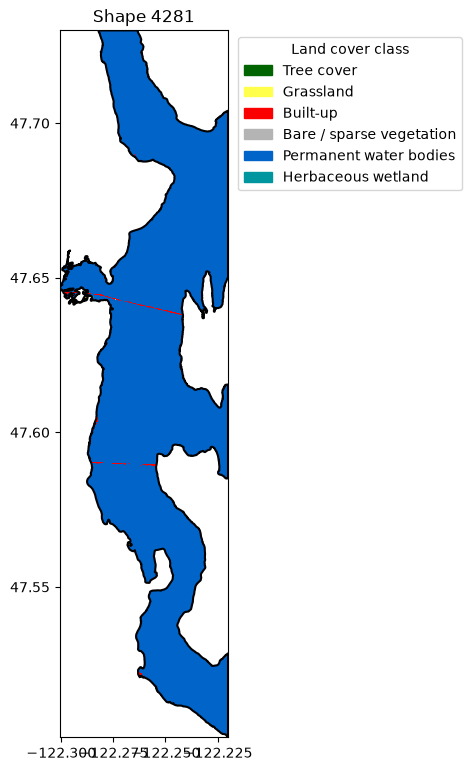

In [11]:
plot_shapes(4281, gdf, clips)

In [12]:
non_valid_geometries.explore()

/var/folders/8x/mv6wnm656dd5pj6tsyt_3tq40000gr/T/ipykernel_31533/858330077.py:1: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  non_valid_geometries.explore()
